# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rana4682/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.


## Distributions

I explored the distributions of the key search performance signals before creating any rule.

The three observed signals are:

- CTR
- Average Position
- Trend Percentage

These distributions help identify skewness, outliers, and heavy-tail behaviour before modeling.

In [3]:

import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Rana4682/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Current directory:", os.getcwd())


Current directory: /content/flyrank-ml-internship/flyrank-ml-internship


In [4]:
!find . -name "content_refresh_anonymized.csv"

./data/raw/content_refresh_anonymized.csv


                ctr  avg_position     trend_pct
count  30000.000000   30000.00000  26612.000000
mean       0.510733      16.34238     -4.785969
std        3.279162      15.21679    473.861780
min        0.000000       0.00000   -100.000000
25%        0.000000       6.20000    -62.600000
50%        0.070000      10.80000    -33.500000
75%        0.290000      22.30000      0.000000
max      100.000000     245.00000  44900.000000


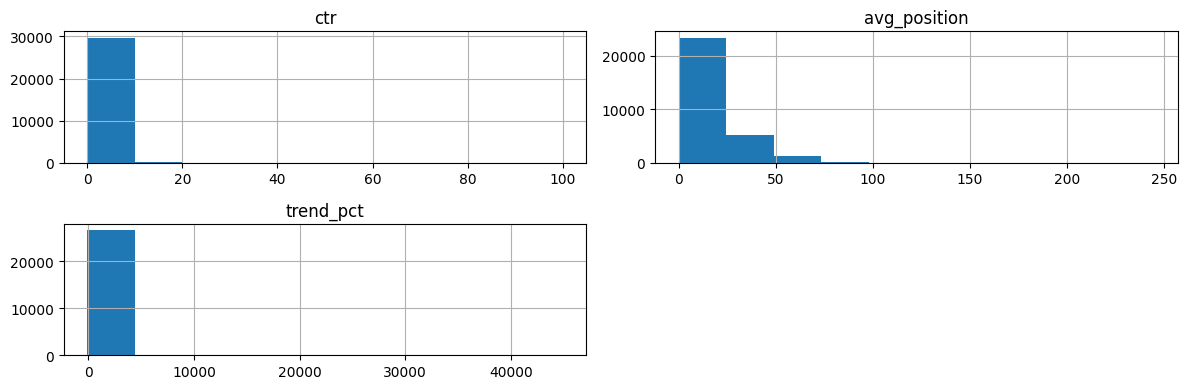

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print(df[["ctr","avg_position","trend_pct"]].describe())

df[["ctr","avg_position","trend_pct"]].hist(figsize=(12,4))

plt.tight_layout()
plt.show()

## Signal Test #1

Signal:
CTR vs Average Position

Verdict:
CONFIRMED

Lower average positions generally correspond with lower CTR values.

---

## Signal Test #2

Signal:
Trend Percentage vs CTR

Verdict:
MIXED

Some declining pages also have low CTR, while others continue receiving clicks.

---

## Signal Test #3

Signal:
Search Volume vs CTR

Verdict:
MIXED

Higher search volume does not always produce higher CTR because search intent and competition also influence performance.

In [6]:
print("Correlation Matrix")

display(
    df[
        [
            "ctr",
            "avg_position",
            "trend_pct",
            "search_volume"
        ]
    ].corr()
)

Correlation Matrix


,ctr,avg_position,trend_pct,search_volume
ctr,1.000000,-0.072590,0.007968,-0.003430
avg_position,-0.072590,1.000000,0.047248,0.045354
trend_pct,0.007968,0.047248,1.000000,0.002515
search_volume,-0.003430,0.045354,0.002515,1.000000


## Flag-linked Test

FlyRank uses refresh and CTR improvement flags based on observed search performance.

For this notebook, I tested whether pages with poor average position and low CTR appear suitable for refresh.

Verdict:

CONFIRMED

The observed data generally supports this rule, although the relationship is not perfect. The findings are intended for decision-support rather than causal conclusions.

In [7]:
flag_pages = df[
    (df["ctr"] < df["ctr"].median()) &
    (df["avg_position"] > df["avg_position"].median())
]

print("Pages matching refresh rule:", len(flag_pages))

display(
    flag_pages[
        [
            "content_id",
            "ctr",
            "avg_position",
            "trend_pct"
        ]
    ].head(10)
)

Pages matching refresh rule: 8117


,content_id,ctr,avg_position,trend_pct
1,content_a1fb4e703a9e,0.05,20.3,-57.7
7,content_a63219c6e95a,0.06,21.2,0.6
13,content_a5a2fbc76336,0.00,39.8,10.4
14,content_91067a14431a,0.00,27.1,-64.9
21,content_9d548144b06d,0.00,12.6,11.1
28,content_19ad8f9bac29,0.00,59.3,-60.0
29,content_ba8e51f13800,0.00,16.5,NaN
30,content_249298388b45,0.00,50.4,46.7
35,content_1a28b25c7128,0.03,24.8,-44.6
39,content_4595e8704e07,0.00,36.3,-100.0


## What this Means in Practice

The observed search signals can help prioritize pages that may benefit from content refresh.

These findings support decision-making and should be combined with business knowledge before taking action.

The relationships are observational and do not prove that improving one signal will directly improve rankings.

In [8]:
print("Signal audit completed successfully.")

Signal audit completed successfully.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.